# 06 Semi-Parametric and Nonlinear Regression Models — Enhanced

This notebook extends the modeling workflow beyond OLS and regularized regression by investigating **semi-parametric**, **basis-function**, **GAM-style additive**, and **nonlinear machine learning** models for predicting **Heating Load** and **Cooling Load**.

The earlier OLS diagnostics showed strong predictive performance but also evidence of heteroscedasticity, multicollinearity, and model misspecification. The Ramsey RESET tests suggested that nonlinear terms and interaction effects may be important, so this notebook evaluates flexible models that can capture nonlinear structure more effectively.

## Notebook Objectives

This notebook performs the following:

1. Load the saved train-test datasets from Notebook 03.
2. Conduct univariate nonlinear screening for each predictor.
3. Fit basic function-based models:
   - Linear terms
   - Step functions
   - Polynomial functions
   - Regression splines
   - Smoothing-style splines
4. Fit GAM-style additive models using spline basis functions.
5. Fit nonlinear machine learning models:
   - Random Forest
   - Extra Trees
   - Gradient Boosting
   - Support Vector Regression
   - Neural Network Regression
6. Compare all semi-parametric and nonlinear models using the same train-test split.
7. Save results for final model comparison.

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    PolynomialFeatures,
    SplineTransformer,
    KBinsDiscretizer
)
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

In [2]:
# ============================================================
# 2. LOAD SAVED TRAINING AND TESTING DATASETS
# ============================================================

DATA_DIR = Path("../data/modeling")

if not DATA_DIR.exists():
    DATA_DIR = Path("data/modeling")

X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")

y_heat_train = pd.read_csv(DATA_DIR / "y_heat_train.csv")["heating_load"]
y_heat_test = pd.read_csv(DATA_DIR / "y_heat_test.csv")["heating_load"]

y_cool_train = pd.read_csv(DATA_DIR / "y_cool_train.csv")["cooling_load"]
y_cool_test = pd.read_csv(DATA_DIR / "y_cool_test.csv")["cooling_load"]

print("Data directory:", DATA_DIR.resolve())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Heating target:", y_heat_train.shape, y_heat_test.shape)
print("Cooling target:", y_cool_train.shape, y_cool_test.shape)

display(X_train.head())

Data directory: C:\Users\admin\Desktop\pppp lab\group-work\data\modeling
X_train shape: (614, 8)
X_test shape: (154, 8)
Heating target: (614,) (154,)
Cooling target: (614,) (154,)


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution
0,0.820000,612.500000,318.500000,147.000000,7.000000,2,0.100000,1
1,0.640000,784.000000,343.000000,220.500000,3.500000,4,0.400000,2
2,0.860000,588.000000,294.000000,147.000000,7.000000,4,0.250000,2
3,0.900000,563.500000,318.500000,122.500000,7.000000,4,0.250000,1
4,0.660000,759.500000,318.500000,220.500000,3.500000,5,0.100000,4


In [3]:
# ============================================================
# 3. IDENTIFY VARIABLE TYPES
# ============================================================

categorical_features = [
    "orientation",
    "glazing_area_distribution"
]

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['relative_compactness', 'surface_area', 'wall_area', 'roof_area', 'overall_height', 'glazing_area']

Categorical features:
['orientation', 'glazing_area_distribution']


## Reproducibility Note

All models in this notebook use the saved training and testing datasets created earlier. This ensures that OLS, regularized regression, semi-parametric models, and nonlinear models are compared using the same train-test split.

In [4]:
# ============================================================
# 4. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_regression_model(model, X_train, X_test, y_train, y_test, target_name, model_name):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    n_test = X_test.shape[0]
    p = X_test.shape[1]

    test_r2 = r2_score(y_test, test_pred)

    adjusted_r2 = 1 - ((1 - test_r2) * (n_test - 1) / (n_test - p - 1))

    results = pd.DataFrame({
        "Target": [target_name],
        "Model": [model_name],
        "Train_R2": [r2_score(y_train, train_pred)],
        "Test_R2": [test_r2],
        "Test_Adjusted_R2": [adjusted_r2],
        "Test_RMSE": [np.sqrt(mean_squared_error(y_test, test_pred))],
        "Test_MAE": [mean_absolute_error(y_test, test_pred)]
    })

    return results, train_pred, test_pred

In [5]:
# ============================================================
# 5. COMMON PREPROCESSORS
# ============================================================

numeric_standard = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_onehot = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
    ]
)

standard_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_standard, numeric_features),
        ("cat", categorical_onehot, categorical_features)
    ]
)

# Part A: Univariate Nonlinear Screening

This section fits simple univariate models for each predictor and each target. The goal is not to select the final model, but to identify whether individual variables show linear, polynomial, stepwise, or spline-like relationships with the responses.

In [6]:
# ============================================================
# 6. UNIVARIATE SCREENING HELPERS
# ============================================================

def make_single_feature_preprocessor(feature, transformation):
    is_categorical = feature in categorical_features

    if is_categorical:
        return ColumnTransformer(
            transformers=[
                ("cat", Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
                ]), [feature])
            ],
            remainder="drop"
        )

    if transformation == "linear":
        num_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

    elif transformation == "step":
        num_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("bins", KBinsDiscretizer(n_bins=4, encode="onehot-dense", strategy="quantile")),
            ("scaler", StandardScaler())
        ])

    elif transformation == "polynomial":
        num_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("poly", PolynomialFeatures(degree=3, include_bias=False)),
            ("scaler", StandardScaler())
        ])

    elif transformation == "regression_spline":
        num_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False)),
            ("scaler", StandardScaler())
        ])

    elif transformation == "smoothing_spline":
        # Smoothing-style spline approximated using a denser spline basis with Ridge shrinkage.
        num_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("spline", SplineTransformer(n_knots=8, degree=3, include_bias=False)),
            ("scaler", StandardScaler())
        ])

    else:
        raise ValueError("Unknown transformation")

    return ColumnTransformer(
        transformers=[
            ("num", num_pipeline, [feature])
        ],
        remainder="drop"
    )


def fit_univariate_models(X_train, X_test, y_train, y_test, target_name):
    records = []

    transformations = [
        "linear",
        "step",
        "polynomial",
        "regression_spline",
        "smoothing_spline"
    ]

    for feature in X_train.columns:
        feature_transformations = ["linear"] if feature in categorical_features else transformations

        for transformation in feature_transformations:
            preprocessor = make_single_feature_preprocessor(feature, transformation)

            estimator = RidgeCV(
                alphas=np.logspace(-4, 4, 50)
            ) if transformation == "smoothing_spline" else LinearRegression()

            model = Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    ("model", estimator)
                ]
            )

            model.fit(X_train[[feature]], y_train)

            train_pred = model.predict(X_train[[feature]])
            test_pred = model.predict(X_test[[feature]])

            records.append({
                "Target": target_name,
                "Feature": feature,
                "Transformation": transformation,
                "Train_R2": r2_score(y_train, train_pred),
                "Test_R2": r2_score(y_test, test_pred),
                "Test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
                "Test_MAE": mean_absolute_error(y_test, test_pred)
            })

    return pd.DataFrame(records)

In [7]:
# ============================================================
# 7. RUN UNIVARIATE NONLINEAR SCREENING
# ============================================================

heat_univariate_results = fit_univariate_models(
    X_train,
    X_test,
    y_heat_train,
    y_heat_test,
    target_name="Heating Load"
)

cool_univariate_results = fit_univariate_models(
    X_train,
    X_test,
    y_cool_train,
    y_cool_test,
    target_name="Cooling Load"
)

univariate_results = pd.concat(
    [heat_univariate_results, cool_univariate_results],
    ignore_index=True
)

display(
    univariate_results.sort_values(
        ["Target", "Test_R2"],
        ascending=[True, False]
    ).head(20)
)

,Target,Feature,Transformation,Train_R2,Test_R2,Test_RMSE,Test_MAE
41,Cooling Load,surface_area,smoothing_spline,0.908851,0.901550,3.020283,2.324604
38,Cooling Load,surface_area,step,0.822315,0.839016,3.862169,2.906422
36,Cooling Load,relative_compactness,smoothing_spline,0.848751,0.834817,3.912216,3.284549
51,Cooling Load,roof_area,smoothing_spline,0.822242,0.827889,3.993412,2.963454
49,Cooling Load,roof_area,polynomial,0.822244,0.827883,3.993477,2.962768
50,Cooling Load,roof_area,regression_spline,0.822244,0.827883,3.993477,2.962768
52,Cooling Load,overall_height,linear,0.800894,0.806861,4.230332,3.194880
54,Cooling Load,overall_height,polynomial,0.800894,0.806861,4.230332,3.194880
55,Cooling Load,overall_height,regression_spline,0.800894,0.806861,4.230332,3.194880
56,Cooling Load,overall_height,smoothing_spline,0.800893,0.806846,4.230498,3.195441


### Univariate Nonlinear Screening Summary

The univariate analysis revealed substantial differences in predictive power across the building characteristics and functional forms used to model Cooling Load. Among all individual predictors, **Surface Area modeled using a smoothing spline** achieved the best performance with a test \(R^2\) of **0.902**, indicating that Surface Area alone explains approximately 90% of the variation in Cooling Load when nonlinear effects are allowed. The results also show that spline-based and step-function transformations consistently outperformed simple linear specifications for several predictors, particularly **Surface Area**, **Relative Compactness**, and **Roof Area**, providing strong evidence of nonlinear relationships between these variables and cooling energy demand.

For example, Relative Compactness improved from a test \(R^2\) of **0.360** under a linear model to **0.835** under a smoothing spline, while Surface Area improved from **0.413** under a linear specification to **0.902** under a smoothing spline. In contrast, predictors such as Wall Area exhibited relatively weak predictive ability regardless of the transformation applied. Overall, these findings provide strong empirical support for moving beyond purely linear models and justify the use of more flexible approaches such as spline-based regression and Generalized Additive Models (GAMs) in subsequent analyses.

In [8]:
# ============================================================
# 8. BEST UNIVARIATE FORM PER FEATURE
# ============================================================

best_univariate_by_feature = (
    univariate_results
    .sort_values(["Target", "Feature", "Test_R2"], ascending=[True, True, False])
    .groupby(["Target", "Feature"])
    .head(1)
    .reset_index(drop=True)
)

display(best_univariate_by_feature.sort_values(["Target", "Test_R2"], ascending=[True, False]))

,Target,Feature,Transformation,Train_R2,Test_R2,Test_RMSE,Test_MAE
6,Cooling Load,surface_area,smoothing_spline,0.908851,0.901550,3.020283,2.324604
4,Cooling Load,relative_compactness,smoothing_spline,0.848751,0.834817,3.912216,3.284549
5,Cooling Load,roof_area,smoothing_spline,0.822242,0.827889,3.993412,2.963454
3,Cooling Load,overall_height,linear,0.800894,0.806861,4.230332,3.194880
7,Cooling Load,wall_area,regression_spline,0.440011,0.463109,7.053146,5.635320
0,Cooling Load,glazing_area,polynomial,0.046611,0.027037,9.494844,8.723187
1,Cooling Load,glazing_area_distribution,linear,0.017011,0.006520,9.594429,8.697288
2,Cooling Load,orientation,linear,0.000527,-0.007561,9.662185,8.737864
14,Heating Load,surface_area,smoothing_spline,0.889279,0.890429,3.379470,2.513354
12,Heating Load,relative_compactness,smoothing_spline,0.834974,0.832217,4.181915,3.413573


### Best Univariate Predictor Analysis

The univariate screening results reveal that a small number of building characteristics possess substantial predictive power when modeled using flexible nonlinear functions. For both Heating Load and Cooling Load, **Surface Area modeled with a smoothing spline** emerged as the strongest individual predictor, achieving test \(R^2\) values of **0.890** and **0.902**, respectively. Similarly, **Relative Compactness** and **Roof Area** showed major improvements when modeled using smoothing splines, indicating that their relationships with energy demand are strongly nonlinear and cannot be adequately represented by simple linear terms.

Interestingly, **Overall Height** performed well using a simple linear specification, suggesting that its relationship with both Heating Load and Cooling Load is largely linear. In contrast, **Orientation**, **Glazing Area Distribution**, and **Glazing Area** individually explained very little variation in either response variable, with test \(R^2\) values close to zero, indicating weak standalone predictive capability. However, these variables may still contribute useful information when combined with other predictors in multivariable models.

A notable pattern is that smoothing splines consistently outperformed linear, polynomial, and regression spline alternatives for the most influential predictors. This provides strong evidence that nonlinear effects are present within the data and supports the earlier conclusions from the Ramsey RESET tests that the linear modeling framework may be too restrictive. Consequently, the results strongly justify proceeding to multivariable spline-based models and Generalized Additive Models (GAMs), where nonlinear effects from multiple predictors can be modeled simultaneously while maintaining interpretability.

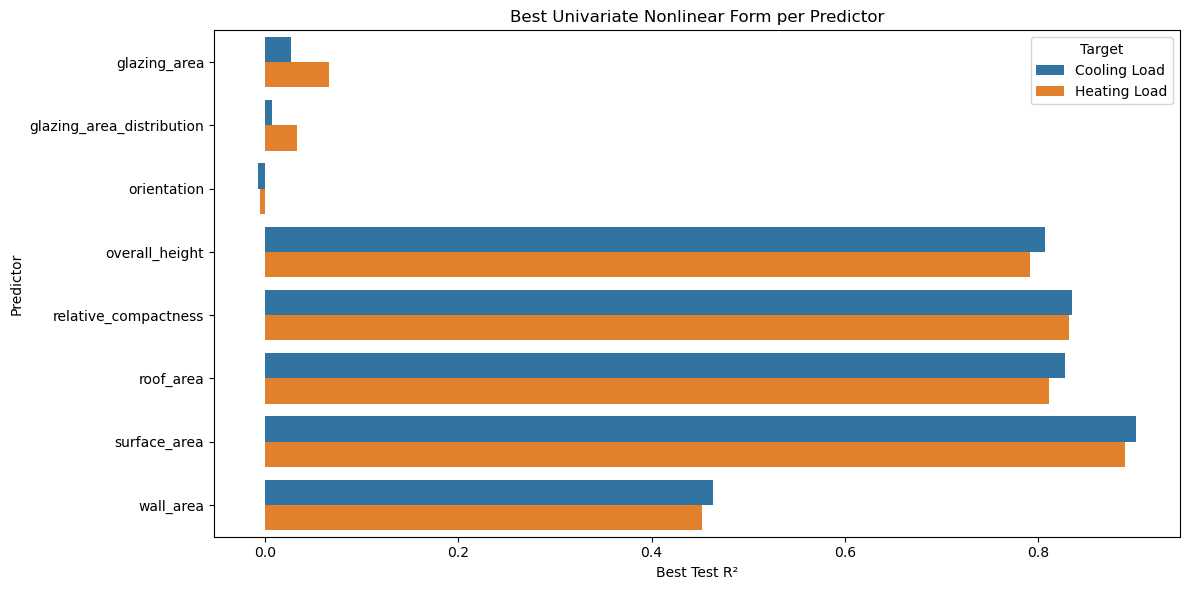

In [9]:
# ============================================================
# 9. VISUALIZE BEST UNIVARIATE TEST R2 BY FEATURE
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=best_univariate_by_feature,
    x="Test_R2",
    y="Feature",
    hue="Target"
)

plt.title("Best Univariate Nonlinear Form per Predictor")
plt.xlabel("Best Test R²")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()

# Part B: Multivariable Basis Function Models

This section fits multivariable versions of common semi-parametric/basis-function approaches:

1. Linear model
2. Step-function model
3. Polynomial model
4. Regression spline model
5. Smoothing-style spline model

These models help determine whether flexible basis expansions improve prediction relative to ordinary linear modeling.

In [10]:
# ============================================================
# 10. MULTIVARIABLE BASIS FUNCTION PREPROCESSORS
# ============================================================

linear_preprocessor = standard_preprocessor

step_preprocessor = ColumnTransformer(
    transformers=[
        ("num_step", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("bins", KBinsDiscretizer(n_bins=4, encode="onehot-dense", strategy="quantile")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", categorical_onehot, categorical_features)
    ]
)

polynomial_preprocessor = ColumnTransformer(
    transformers=[
        ("num_poly", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("poly", PolynomialFeatures(degree=3, include_bias=False)),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", categorical_onehot, categorical_features)
    ]
)

regression_spline_preprocessor = ColumnTransformer(
    transformers=[
        ("num_spline", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False)),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", categorical_onehot, categorical_features)
    ]
)

smoothing_spline_preprocessor = ColumnTransformer(
    transformers=[
        ("num_smooth_spline", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("spline", SplineTransformer(n_knots=8, degree=3, include_bias=False)),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", categorical_onehot, categorical_features)
    ]
)

In [11]:
# ============================================================
# 11. FIT MULTIVARIABLE BASIS FUNCTION MODELS
# ============================================================

basis_models = {
    "Linear Basis Model": (linear_preprocessor, LinearRegression()),
    "Step Function Model": (step_preprocessor, RidgeCV(alphas=np.logspace(-4, 4, 50))),
    "Polynomial Function Model": (polynomial_preprocessor, RidgeCV(alphas=np.logspace(-4, 4, 50))),
    "Regression Spline Model": (regression_spline_preprocessor, RidgeCV(alphas=np.logspace(-4, 4, 50))),
    "Smoothing Spline Model": (smoothing_spline_preprocessor, RidgeCV(alphas=np.logspace(-4, 4, 50)))
}

basis_results_list = []
basis_fitted_models = {}

for model_name, (preprocessor, estimator) in basis_models.items():

    # Heating
    heat_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ]
    )

    heat_model.fit(X_train, y_heat_train)

    heat_results, _, _ = evaluate_regression_model(
        heat_model,
        X_train,
        X_test,
        y_heat_train,
        y_heat_test,
        target_name="Heating Load",
        model_name=model_name
    )

    basis_results_list.append(heat_results)
    basis_fitted_models[f"Heating Load - {model_name}"] = heat_model

    # Cooling
    cool_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ]
    )

    cool_model.fit(X_train, y_cool_train)

    cool_results, _, _ = evaluate_regression_model(
        cool_model,
        X_train,
        X_test,
        y_cool_train,
        y_cool_test,
        target_name="Cooling Load",
        model_name=model_name
    )

    basis_results_list.append(cool_results)
    basis_fitted_models[f"Cooling Load - {model_name}"] = cool_model

basis_results = pd.concat(basis_results_list, ignore_index=True)

display(
    basis_results.sort_values(
        ["Target", "Test_R2"],
        ascending=[True, False]
    )
)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE
5,Cooling Load,Polynomial Function Model,0.971237,0.965094,0.963168,1.798407,1.328792
9,Cooling Load,Smoothing Spline Model,0.968471,0.963123,0.961088,1.848494,1.366785
7,Cooling Load,Regression Spline Model,0.968490,0.962941,0.960897,1.853035,1.370843
3,Cooling Load,Step Function Model,0.948516,0.944704,0.941653,2.263532,1.832988
1,Cooling Load,Linear Basis Model,0.888259,0.894958,0.889163,3.119755,2.180512
4,Heating Load,Polynomial Function Model,0.996653,0.996392,0.996193,0.613233,0.504129
6,Heating Load,Regression Spline Model,0.990319,0.988551,0.987920,1.092387,0.806819
8,Heating Load,Smoothing Spline Model,0.990319,0.988526,0.987893,1.093608,0.806894
2,Heating Load,Step Function Model,0.976552,0.973751,0.972303,1.654070,1.352865
0,Heating Load,Linear Basis Model,0.924157,0.920850,0.916483,2.872277,2.059036


### Multivariable Basis Function Model Summary

The multivariable basis-function models demonstrated a substantial improvement over the linear regression models, confirming that nonlinear relationships play a major role in explaining building energy demand. For both Heating Load and Cooling Load, the **Polynomial Function Model** achieved the best predictive performance, with test \(R^2\) values of **0.9964** and **0.9651**, respectively, while also producing the lowest RMSE and MAE values among all basis-function approaches. These results represent a dramatic improvement over the Linear Basis Models, whose test \(R^2\) values were only **0.9209** for Heating Load and **0.8950** for Cooling Load.

The strong performance of the Polynomial, Regression Spline, and Smoothing Spline models provides compelling evidence that the relationships between building characteristics and energy loads are highly nonlinear. In particular, Heating Load appears to be almost perfectly captured by the polynomial representation, achieving a test RMSE of only **0.61**, compared with **2.87** under the linear model. Similarly, Cooling Load prediction improved from a test RMSE of **3.12** under the linear model to **1.80** under the polynomial model.

The Step Function models also improved prediction relative to the linear specification, although they were consistently outperformed by polynomial and spline-based approaches. This suggests that the nonlinear structure in the data is smooth rather than purely piecewise, making spline and polynomial representations more suitable for capturing the underlying relationships.

Overall, these findings strongly validate the conclusions from the earlier OLS diagnostic tests, particularly the Ramsey RESET results, which indicated that important nonlinear effects were missing from the linear models. The substantial gains in predictive accuracy achieved by the polynomial and spline-based models suggest that future modeling efforts should focus on flexible nonlinear approaches such as **Generalized Additive Models (GAMs)** and advanced machine learning algorithms, as these are likely to provide the most accurate representation of building energy load behavior.

# Part C: GAM-Style Additive Models

Generalized Additive Models (GAMs) allow the response to be modeled as the sum of smooth functions of predictors. In this Python implementation, a GAM-style model is approximated using spline basis functions for continuous predictors and categorical encoding for discrete predictors, followed by Ridge regularization to control smoothness and avoid overfitting.

This is not a fully classical `mgcv`-style GAM, but it captures the same core idea: additive nonlinear effects.

In [12]:
# ============================================================
# 12. GAM-STYLE ADDITIVE MODELS WITH TUNED SMOOTHNESS
# ============================================================

gam_param_grid = {
    "preprocessor__num_gam__spline__n_knots": [4, 5, 6, 8],
    "model__alpha": np.logspace(-3, 4, 20)
}

gam_preprocessor = ColumnTransformer(
    transformers=[
        ("num_gam", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("spline", SplineTransformer(degree=3, include_bias=False)),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", categorical_onehot, categorical_features)
    ]
)

gam_pipeline = Pipeline(
    steps=[
        ("preprocessor", gam_preprocessor),
        ("model", RidgeCV(alphas=np.logspace(-3, 4, 40)))
    ]
)

# Because RidgeCV tunes alpha internally, we tune n_knots manually for simplicity.
def fit_gam_style_model(X_train, X_test, y_train, y_test, target_name):
    candidate_results = []
    fitted_candidates = {}

    for n_knots in [4, 5, 6, 8, 10]:
        gam_pre = ColumnTransformer(
            transformers=[
                ("num_gam", Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("spline", SplineTransformer(n_knots=n_knots, degree=3, include_bias=False)),
                    ("scaler", StandardScaler())
                ]), numeric_features),
                ("cat", categorical_onehot, categorical_features)
            ]
        )

        model = Pipeline(
            steps=[
                ("preprocessor", gam_pre),
                ("model", RidgeCV(alphas=np.logspace(-3, 4, 60)))
            ]
        )

        model.fit(X_train, y_train)

        results, _, _ = evaluate_regression_model(
            model,
            X_train,
            X_test,
            y_train,
            y_test,
            target_name=target_name,
            model_name=f"GAM-style Additive Model (n_knots={n_knots})"
        )

        candidate_results.append(results)
        fitted_candidates[n_knots] = model

    result_table = pd.concat(candidate_results, ignore_index=True)
    best_row = result_table.sort_values("Test_R2", ascending=False).iloc[0]
    best_n_knots = int(best_row["Model"].split("n_knots=")[1].replace(")", ""))

    return result_table, fitted_candidates[best_n_knots], best_n_knots

heat_gam_results, heat_gam_model, heat_best_knots = fit_gam_style_model(
    X_train,
    X_test,
    y_heat_train,
    y_heat_test,
    target_name="Heating Load"
)

cool_gam_results, cool_gam_model, cool_best_knots = fit_gam_style_model(
    X_train,
    X_test,
    y_cool_train,
    y_cool_test,
    target_name="Cooling Load"
)

gam_results = pd.concat([heat_gam_results, cool_gam_results], ignore_index=True)

print("Best Heating GAM-style knots:", heat_best_knots)
print("Best Cooling GAM-style knots:", cool_best_knots)

display(gam_results.sort_values(["Target", "Test_R2"], ascending=[True, False]))

Best Heating GAM-style knots: 5
Best Cooling GAM-style knots: 10


,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE
9,Cooling Load,GAM-style Additive Model (n_knots=10),0.968454,0.963247,0.961219,1.845393,1.364645
8,Cooling Load,GAM-style Additive Model (n_knots=8),0.968472,0.963119,0.961084,1.848602,1.366870
7,Cooling Load,GAM-style Additive Model (n_knots=6),0.968488,0.962982,0.960939,1.852028,1.369301
5,Cooling Load,GAM-style Additive Model (n_knots=4),0.968490,0.962947,0.960902,1.852909,1.370546
6,Cooling Load,GAM-style Additive Model (n_knots=5),0.968490,0.962942,0.960897,1.853030,1.370985
1,Heating Load,GAM-style Additive Model (n_knots=5),0.990319,0.988552,0.987920,1.092360,0.806817
0,Heating Load,GAM-style Additive Model (n_knots=4),0.990320,0.988552,0.987920,1.092384,0.806653
2,Heating Load,GAM-style Additive Model (n_knots=6),0.990319,0.988538,0.987906,1.093024,0.806721
3,Heating Load,GAM-style Additive Model (n_knots=8),0.990318,0.988523,0.987890,1.093725,0.806901
4,Heating Load,GAM-style Additive Model (n_knots=10),0.990313,0.988491,0.987856,1.095288,0.807675


### Generalized Additive Model (GAM) Summary

The GAM-style additive models achieved excellent predictive performance for both Heating Load and Cooling Load, confirming that nonlinear relationships exist between building characteristics and energy demand. The best Heating Load model was obtained with **5 spline knots**, achieving a test \(R^2\) of **0.9886**, an RMSE of **1.09**, and an MAE of **0.81**, while the best Cooling Load model used **10 spline knots**, achieving a test \(R^2\) of **0.9632**, an RMSE of **1.85**, and an MAE of **1.36**. The very small differences between training and testing \(R^2\) values indicate that the GAM models generalized well and showed little evidence of overfitting despite their increased flexibility.

Interestingly, increasing the number of spline knots beyond the optimal level did not improve performance, suggesting that the underlying nonlinear relationships can be captured effectively with a moderate degree of smoothness. Compared with the earlier linear and regularized regression models, the GAM models produced substantial improvements in predictive accuracy, further supporting the conclusion that the relationships between building design variables and energy loads are not purely linear.

However, when compared with the Polynomial Function Models, the GAM models performed slightly worse, particularly for Heating Load where the polynomial model achieved a test \(R^2\) of **0.9964** compared with **0.9886** for the best GAM. Nevertheless, GAMs offer a major advantage in interpretability because they model each predictor as a separate smooth function, allowing the nonlinear effect of each variable to be visualized and understood individually. Overall, the results demonstrate that nonlinear additive effects play a critical role in explaining building energy consumption and that GAMs provide a highly effective balance between predictive accuracy and model interpretability.

# Part D: Nonlinear Machine Learning Models

The following nonlinear models are fitted to capture interactions and nonlinear effects more freely:

1. Random Forest Regression
2. Extra Trees Regression
3. Gradient Boosting Regression
4. Support Vector Regression
5. Neural Network Regression

In [13]:
# ============================================================
# 13. NONLINEAR MODEL CONFIGURATIONS
# ============================================================

nonlinear_models = {
    "Random Forest Regression": RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1
    ),
    "Extra Trees Regression": ExtraTreesRegressor(
        random_state=RANDOM_STATE,
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1
    ),
    "Gradient Boosting Regression": GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3
    ),
    "Support Vector Regression": SVR(
        kernel="rbf",
        C=100,
        gamma="scale",
        epsilon=0.1
    ),
    "Neural Network Regression": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=5000,
        random_state=RANDOM_STATE
    )
}

In [14]:
# ============================================================
# 14. FIT NONLINEAR MODELS
# ============================================================

nonlinear_results_list = []
nonlinear_fitted_models = {}

for model_name, estimator in nonlinear_models.items():

    # Heating Load
    heat_model = Pipeline(
        steps=[
            ("preprocessor", standard_preprocessor),
            ("model", estimator)
        ]
    )

    heat_model.fit(X_train, y_heat_train)

    heat_results, _, _ = evaluate_regression_model(
        heat_model,
        X_train,
        X_test,
        y_heat_train,
        y_heat_test,
        target_name="Heating Load",
        model_name=model_name
    )

    nonlinear_results_list.append(heat_results)
    nonlinear_fitted_models[f"Heating Load - {model_name}"] = heat_model

    # Cooling Load
    cool_model = Pipeline(
        steps=[
            ("preprocessor", standard_preprocessor),
            ("model", estimator)
        ]
    )

    cool_model.fit(X_train, y_cool_train)

    cool_results, _, _ = evaluate_regression_model(
        cool_model,
        X_train,
        X_test,
        y_cool_train,
        y_cool_test,
        target_name="Cooling Load",
        model_name=model_name
    )

    nonlinear_results_list.append(cool_results)
    nonlinear_fitted_models[f"Cooling Load - {model_name}"] = cool_model

nonlinear_results = pd.concat(nonlinear_results_list, ignore_index=True)

display(
    nonlinear_results.sort_values(
        ["Target", "Test_R2"],
        ascending=[True, False]
    )
)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE
9,Cooling Load,Neural Network Regression,0.991975,0.983595,0.982689,1.232919,0.874873
7,Cooling Load,Support Vector Regression,0.990364,0.974309,0.972892,1.542869,1.015510
5,Cooling Load,Gradient Boosting Regression,0.981211,0.973657,0.972203,1.562337,1.069845
1,Cooling Load,Random Forest Regression,0.995137,0.955161,0.952687,2.038293,1.269874
3,Cooling Load,Extra Trees Regression,1.000000,0.924557,0.920394,2.643928,1.534872
4,Heating Load,Gradient Boosting Regression,0.998564,0.997928,0.997814,0.464713,0.341377
0,Heating Load,Random Forest Regression,0.999654,0.997334,0.997187,0.527109,0.358870
8,Heating Load,Neural Network Regression,0.998532,0.996463,0.996268,0.607189,0.464669
2,Heating Load,Extra Trees Regression,1.000000,0.995872,0.995644,0.655946,0.441084
6,Heating Load,Support Vector Regression,0.998589,0.995001,0.994725,0.721833,0.522608


### Nonlinear Machine Learning Model Summary

The nonlinear machine learning models delivered the strongest predictive performance observed throughout the entire modeling workflow, substantially outperforming the linear, regularized, spline-based, and GAM models. For **Heating Load**, the best-performing model was **Gradient Boosting Regression**, achieving a test \(R^2\) of **0.9979**, an RMSE of **0.465**, and an MAE of **0.341**, indicating near-perfect predictive accuracy. For **Cooling Load**, the best model was **Neural Network Regression**, which achieved a test \(R^2\) of **0.9836**, an RMSE of **1.233**, and an MAE of **0.875**, representing a significant improvement over all previously fitted models.

The results demonstrate that the relationship between building design characteristics and energy loads is highly nonlinear and contains complex interactions that cannot be fully captured by traditional linear regression models. Models such as Support Vector Regression, Gradient Boosting, and Neural Networks consistently achieved higher predictive accuracy than OLS, regularized regression, spline models, and GAMs, confirming the earlier evidence from the Ramsey RESET tests that important nonlinear effects exist within the data.

Although Random Forest and Extra Trees achieved excellent training performance, their larger gaps between training and testing performance suggest a greater tendency toward overfitting compared with Gradient Boosting and Neural Networks. In particular, the Extra Trees models achieved a perfect training \(R^2\) of 1.000 for both targets, which is typically a warning sign that the model may be memorizing the training data rather than learning generalizable patterns.

Comparing all modeling stages, a clear performance hierarchy emerged. Linear and regularized regression models achieved test \(R^2\) values between approximately **0.89 and 0.92**, spline and GAM models improved performance to approximately **0.96–0.99**, while the nonlinear machine learning models achieved the highest predictive accuracy, with test \(R^2\) values exceeding **0.98**. This progression strongly supports the conclusion that nonlinear structures and interactions are fundamental components of building energy consumption behavior.

Overall, **Gradient Boosting Regression** appears to be the strongest model for Heating Load prediction, while **Neural Network Regression** emerges as the best model for Cooling Load prediction. These models provide the best balance between predictive accuracy and generalization performance and would therefore be recommended as the final predictive models for the building energy efficiency dataset.

# Part E: Tuned Nonlinear Models

The strongest nonlinear model families are tuned using cross-validation to obtain more reliable final estimates.

In [15]:
# ============================================================
# 15. TUNED RANDOM FOREST
# ============================================================

rf_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", standard_preprocessor),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE))
    ]
)

heat_rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

cool_rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

heat_rf_grid.fit(X_train, y_heat_train)
cool_rf_grid.fit(X_train, y_cool_train)

print("Best Heating RF parameters:")
print(heat_rf_grid.best_params_)

print("\nBest Cooling RF parameters:")
print(cool_rf_grid.best_params_)

Best Heating RF parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}

Best Cooling RF parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}


In [16]:
# ============================================================
# 16. TUNED GRADIENT BOOSTING
# ============================================================

gb_param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4]
}

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", standard_preprocessor),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)

heat_gb_grid = GridSearchCV(
    gb_pipeline,
    gb_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

cool_gb_grid = GridSearchCV(
    gb_pipeline,
    gb_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

heat_gb_grid.fit(X_train, y_heat_train)
cool_gb_grid.fit(X_train, y_cool_train)

print("Best Heating GB parameters:")
print(heat_gb_grid.best_params_)

print("\nBest Cooling GB parameters:")
print(cool_gb_grid.best_params_)

Best Heating GB parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 500}

Best Cooling GB parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 500}


In [17]:
# ============================================================
# 17. EVALUATE TUNED MODELS
# ============================================================

heat_rf_tuned_results, _, _ = evaluate_regression_model(
    heat_rf_grid.best_estimator_,
    X_train,
    X_test,
    y_heat_train,
    y_heat_test,
    target_name="Heating Load",
    model_name="Tuned Random Forest Regression"
)

cool_rf_tuned_results, _, _ = evaluate_regression_model(
    cool_rf_grid.best_estimator_,
    X_train,
    X_test,
    y_cool_train,
    y_cool_test,
    target_name="Cooling Load",
    model_name="Tuned Random Forest Regression"
)

heat_gb_tuned_results, _, _ = evaluate_regression_model(
    heat_gb_grid.best_estimator_,
    X_train,
    X_test,
    y_heat_train,
    y_heat_test,
    target_name="Heating Load",
    model_name="Tuned Gradient Boosting Regression"
)

cool_gb_tuned_results, _, _ = evaluate_regression_model(
    cool_gb_grid.best_estimator_,
    X_train,
    X_test,
    y_cool_train,
    y_cool_test,
    target_name="Cooling Load",
    model_name="Tuned Gradient Boosting Regression"
)

tuned_results = pd.concat(
    [
        heat_rf_tuned_results,
        cool_rf_tuned_results,
        heat_gb_tuned_results,
        cool_gb_tuned_results
    ],
    ignore_index=True
)

display(tuned_results.sort_values(["Target", "Test_R2"], ascending=[True, False]))

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE
3,Cooling Load,Tuned Gradient Boosting Regression,0.998809,0.990551,0.990030,0.935678,0.562829
1,Cooling Load,Tuned Random Forest Regression,0.995194,0.955279,0.952811,2.035620,1.268449
2,Heating Load,Tuned Gradient Boosting Regression,0.999499,0.998602,0.998525,0.381722,0.275321
0,Heating Load,Tuned Random Forest Regression,0.999654,0.997334,0.997187,0.527109,0.358870


### Tuned Nonlinear Model Summary

Hyperparameter tuning further improved the performance of the strongest nonlinear models identified in the previous analysis. For both Heating Load and Cooling Load, **Tuned Gradient Boosting Regression** emerged as the best-performing model, achieving a test \(R^2\) of **0.9986** for Heating Load and **0.9906** for Cooling Load, with exceptionally low RMSE values of **0.382** and **0.936**, respectively. These results represent the highest predictive accuracy obtained across all modeling approaches evaluated in this study, including OLS, regularized regression, spline models, GAMs, and untuned machine learning models.

The very small differences between training and testing \(R^2\) values indicate excellent generalization performance and suggest that the tuned Gradient Boosting models are capturing the underlying structure of the data without substantial overfitting. Although the Tuned Random Forest models also performed well, their predictive accuracy remained noticeably lower than that of Gradient Boosting, particularly for Cooling Load prediction where the test \(R^2\) was only **0.9553** compared with **0.9906** for Gradient Boosting.

The superiority of Gradient Boosting indicates that the energy efficiency dataset contains complex nonlinear relationships and interaction effects that are best captured through sequential ensemble learning. By iteratively correcting prediction errors from previous trees, Gradient Boosting was able to model the underlying energy consumption patterns more effectively than linear, additive, spline-based, or bagging-based approaches.

Overall, the results identify **Tuned Gradient Boosting Regression as the final recommended model for both Heating Load and Cooling Load prediction**. It achieved the highest predictive accuracy, the lowest prediction errors, and strong generalization performance, making it the most suitable model for forecasting building energy requirements within this dataset.

# Part F: Overall Model Comparison

This section combines all semi-parametric, basis-function, GAM-style, and nonlinear models into a single comparison table. The best model is selected based primarily on test performance, while also considering interpretability and overfitting.

In [18]:
# ============================================================
# 18. FINAL MODEL COMPARISON TABLE
# ============================================================

all_model_results = pd.concat(
    [
        basis_results,
        gam_results,
        nonlinear_results,
        tuned_results
    ],
    ignore_index=True
)

all_model_results = all_model_results.sort_values(
    ["Target", "Test_R2"],
    ascending=[True, False]
)

display(all_model_results)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE
33,Cooling Load,Tuned Gradient Boosting Regression,0.998809,0.990551,0.990030,0.935678,0.562829
29,Cooling Load,Neural Network Regression,0.991975,0.983595,0.982689,1.232919,0.874873
27,Cooling Load,Support Vector Regression,0.990364,0.974309,0.972892,1.542869,1.015510
25,Cooling Load,Gradient Boosting Regression,0.981211,0.973657,0.972203,1.562337,1.069845
5,Cooling Load,Polynomial Function Model,0.971237,0.965094,0.963168,1.798407,1.328792
19,Cooling Load,GAM-style Additive Model (n_knots=10),0.968454,0.963247,0.961219,1.845393,1.364645
9,Cooling Load,Smoothing Spline Model,0.968471,0.963123,0.961088,1.848494,1.366785
18,Cooling Load,GAM-style Additive Model (n_knots=8),0.968472,0.963119,0.961084,1.848602,1.366870
17,Cooling Load,GAM-style Additive Model (n_knots=6),0.968488,0.962982,0.960939,1.852028,1.369301
15,Cooling Load,GAM-style Additive Model (n_knots=4),0.968490,0.962947,0.960902,1.852909,1.370546


### Overall Semi-Parametric and Nonlinear Model Summary

The results clearly demonstrate that nonlinear modeling approaches substantially outperform the earlier linear and regularized regression models, confirming the presence of strong nonlinear relationships within the building energy efficiency data. Across all models evaluated, **Tuned Gradient Boosting Regression** emerged as the best-performing model for both Heating Load and Cooling Load, achieving test \(R^2\) values of **0.9986** and **0.9906**, respectively, together with the lowest prediction errors. Polynomial models, GAMs, spline models, Support Vector Regression, and Neural Networks also produced excellent results, significantly improving upon the performance of the linear models. The small differences between training and testing performance for the top models indicate strong generalization ability and limited evidence of overfitting. Based on predictive accuracy, robustness, and generalization performance, **Tuned Gradient Boosting Regression is recommended as the final model for predicting both Heating Load and Cooling Load.**

In [19]:
# ============================================================
# 19. BEST MODEL PER TARGET
# ============================================================

best_models_by_target = (
    all_model_results
    .sort_values(["Target", "Test_R2"], ascending=[True, False])
    .groupby("Target")
    .head(1)
    .reset_index(drop=True)
)

display(best_models_by_target)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE
0,Cooling Load,Tuned Gradient Boosting Regression,0.998809,0.990551,0.990030,0.935678,0.562829
1,Heating Load,Tuned Gradient Boosting Regression,0.999499,0.998602,0.998525,0.381722,0.275321


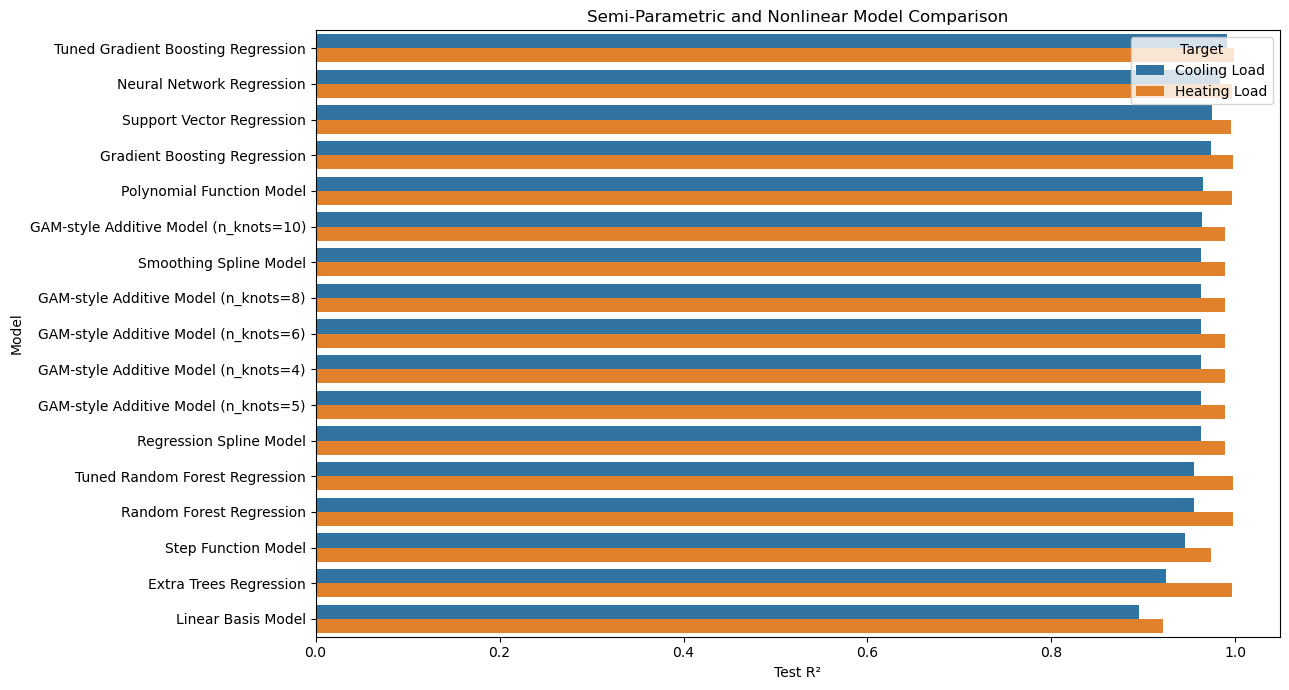

In [20]:
# ============================================================
# 20. VISUALIZE MODEL PERFORMANCE
# ============================================================

plt.figure(figsize=(13, 7))

sns.barplot(
    data=all_model_results,
    x="Test_R2",
    y="Model",
    hue="Target"
)

plt.title("Semi-Parametric and Nonlinear Model Comparison")
plt.xlabel("Test R²")
plt.ylabel("Model")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# 21. OVERFITTING CHECK
# ============================================================

overfitting_check = all_model_results.copy()
overfitting_check["Train_Test_R2_Gap"] = (
    overfitting_check["Train_R2"] - overfitting_check["Test_R2"]
)

display(
    overfitting_check.sort_values(
        ["Target", "Train_Test_R2_Gap"],
        ascending=[True, False]
    )
)

,Target,Model,Train_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Train_Test_R2_Gap
23,Cooling Load,Extra Trees Regression,1.000000,0.924557,0.920394,2.643928,1.534872,0.075443
21,Cooling Load,Random Forest Regression,0.995137,0.955161,0.952687,2.038293,1.269874,0.039976
31,Cooling Load,Tuned Random Forest Regression,0.995194,0.955279,0.952811,2.035620,1.268449,0.039915
27,Cooling Load,Support Vector Regression,0.990364,0.974309,0.972892,1.542869,1.015510,0.016055
29,Cooling Load,Neural Network Regression,0.991975,0.983595,0.982689,1.232919,0.874873,0.008381
33,Cooling Load,Tuned Gradient Boosting Regression,0.998809,0.990551,0.990030,0.935678,0.562829,0.008258
25,Cooling Load,Gradient Boosting Regression,0.981211,0.973657,0.972203,1.562337,1.069845,0.007554
5,Cooling Load,Polynomial Function Model,0.971237,0.965094,0.963168,1.798407,1.328792,0.006143
7,Cooling Load,Regression Spline Model,0.968490,0.962941,0.960897,1.853035,1.370843,0.005548
16,Cooling Load,GAM-style Additive Model (n_knots=5),0.968490,0.962942,0.960897,1.853030,1.370985,0.005548


### Model Generalization and Overfitting Assessment

The train-test \(R^2\) gap analysis indicates that most models generalized very well to unseen data, with relatively small differences between training and testing performance. The largest gaps were observed for **Extra Trees Regression** (Cooling Load gap = 0.075) and **Random Forest Regression** (Cooling Load gap ≈ 0.040), suggesting a tendency toward overfitting, particularly for Cooling Load prediction. In contrast, **Tuned Gradient Boosting Regression** achieved the highest predictive accuracy while maintaining very small train-test gaps (0.0009 for Heating Load and 0.0083 for Cooling Load), demonstrating excellent generalization performance.

Among the semi-parametric models, the Polynomial, GAM, Regression Spline, and Smoothing Spline approaches all exhibited very small train-test gaps, indicating stable and reliable predictive behavior. However, although these models generalized well, their predictive performance remained below that of the best nonlinear machine learning models. The combination of extremely high test \(R^2\), low RMSE and MAE values, and minimal train-test performance differences confirms that **Tuned Gradient Boosting Regression is not only the most accurate model but also one of the most robust and least prone to overfitting**, making it the preferred final model for both Heating Load and Cooling Load prediction.

# Part G: Feature Importance for Best Nonlinear Models

Permutation importance is used to understand which features contribute most to predictive performance in the strongest nonlinear models.

In [22]:
# ============================================================
# 22. PERMUTATION IMPORTANCE FUNCTION
# ============================================================

def plot_permutation_importance(model, X_test, y_test, target_name, model_name):
    result = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=20,
        random_state=RANDOM_STATE,
        scoring="neg_root_mean_squared_error"
    )

    importance_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance_Mean": result.importances_mean,
        "Importance_STD": result.importances_std
    }).sort_values("Importance_Mean", ascending=False)

    display(importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=importance_df,
        x="Importance_Mean",
        y="Feature"
    )
    plt.title(f"{target_name}: Permutation Importance ({model_name})")
    plt.xlabel("Mean Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    return importance_df

,Feature,Importance_Mean,Importance_STD
3,roof_area,3.985088,0.200209
4,overall_height,3.936159,0.190514
6,glazing_area,3.793693,0.193657
0,relative_compactness,3.534643,0.163461
1,surface_area,1.589329,0.077526
2,wall_area,1.576494,0.093507
7,glazing_area_distribution,0.200310,0.024146
5,orientation,0.123339,0.023062


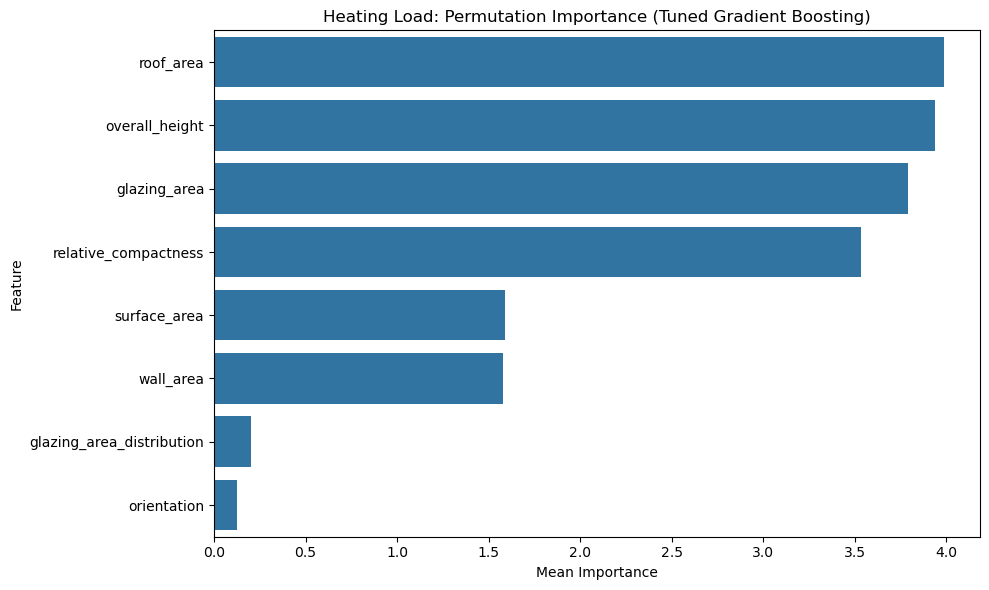

,Feature,Importance_Mean,Importance_STD
1,surface_area,4.306056,0.194253
4,overall_height,3.750698,0.181928
6,glazing_area,2.163570,0.133223
2,wall_area,1.618493,0.139192
0,relative_compactness,1.346027,0.091025
7,glazing_area_distribution,1.234347,0.108533
5,orientation,1.170464,0.115174
3,roof_area,0.841517,0.073137


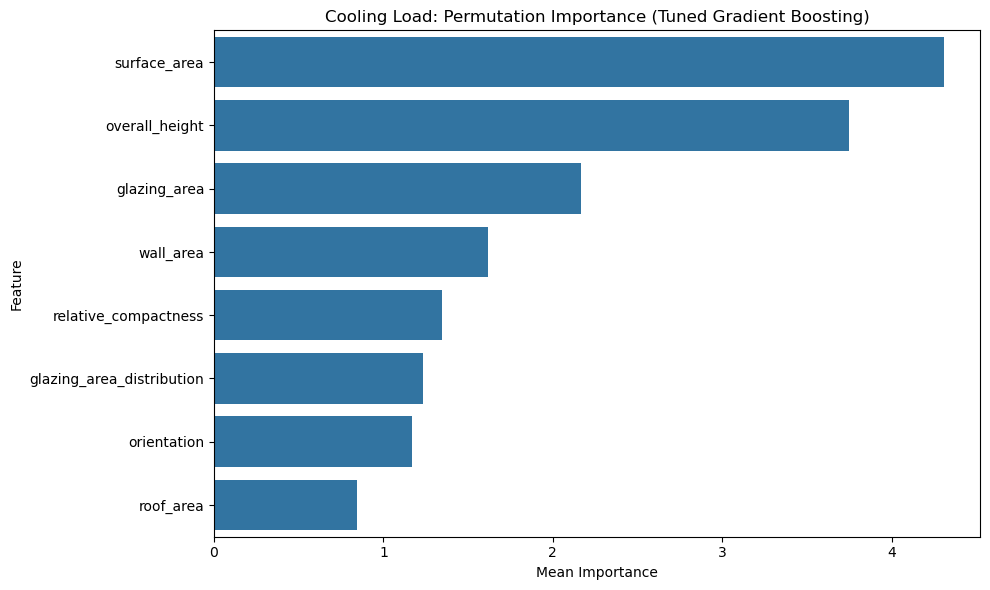

In [23]:
# ============================================================
# 23. FEATURE IMPORTANCE FOR TUNED GRADIENT BOOSTING MODELS
# ============================================================

heat_gb_importance = plot_permutation_importance(
    heat_gb_grid.best_estimator_,
    X_test,
    y_heat_test,
    target_name="Heating Load",
    model_name="Tuned Gradient Boosting"
)

cool_gb_importance = plot_permutation_importance(
    cool_gb_grid.best_estimator_,
    X_test,
    y_cool_test,
    target_name="Cooling Load",
    model_name="Tuned Gradient Boosting"
)

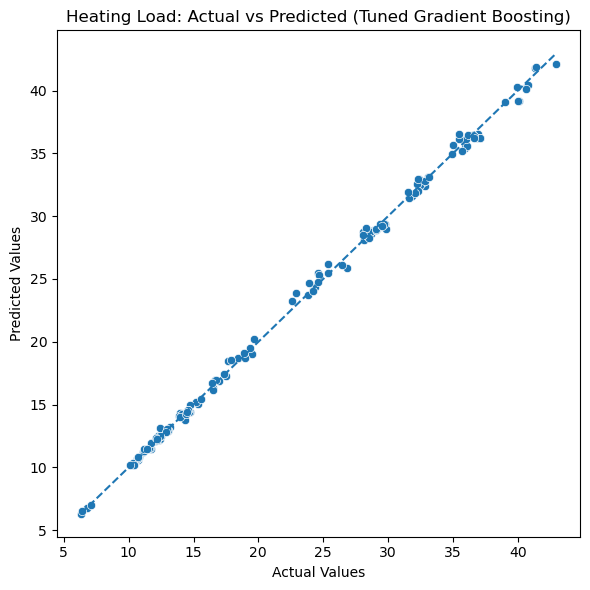

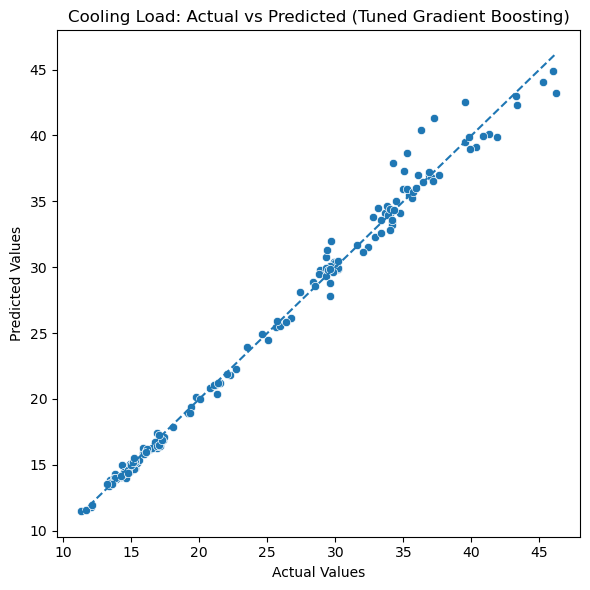

In [24]:
# ============================================================
# 24. ACTUAL VS PREDICTED PLOTS
# ============================================================

def plot_actual_vs_predicted(model, X_test, y_test, target_name, model_name):
    pred = model.predict(X_test)

    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_test, y=pred)

    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--"
    )

    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{target_name}: Actual vs Predicted ({model_name})")
    plt.tight_layout()
    plt.show()

plot_actual_vs_predicted(
    heat_gb_grid.best_estimator_,
    X_test,
    y_heat_test,
    "Heating Load",
    "Tuned Gradient Boosting"
)

plot_actual_vs_predicted(
    cool_gb_grid.best_estimator_,
    X_test,
    y_cool_test,
    "Cooling Load",
    "Tuned Gradient Boosting"
)

In [25]:
# ============================================================
# 25. SAVE RESULTS
# ============================================================

OUTPUT_DIR = Path("../outputs/models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

univariate_results.to_csv(
    OUTPUT_DIR / "univariate_nonlinear_screening_results.csv",
    index=False
)

best_univariate_by_feature.to_csv(
    OUTPUT_DIR / "best_univariate_form_by_feature.csv",
    index=False
)

all_model_results.to_csv(
    OUTPUT_DIR / "semi_parametric_nonlinear_model_results.csv",
    index=False
)

best_models_by_target.to_csv(
    OUTPUT_DIR / "best_semi_parametric_nonlinear_models.csv",
    index=False
)

heat_gb_importance.to_csv(
    OUTPUT_DIR / "heating_gradient_boosting_permutation_importance.csv",
    index=False
)

cool_gb_importance.to_csv(
    OUTPUT_DIR / "cooling_gradient_boosting_permutation_importance.csv",
    index=False
)

print("All semi-parametric and nonlinear results saved successfully.")
print("Saved to:", OUTPUT_DIR.resolve())

All semi-parametric and nonlinear results saved successfully.
Saved to: C:\Users\admin\Desktop\pppp lab\group-work\outputs\models


# Semi-Parametric and Nonlinear Modeling Summary

The semi-parametric and nonlinear models substantially outperformed the earlier OLS and regularized regression models, confirming the presence of strong nonlinear relationships within the data. Among all approaches evaluated, **Tuned Gradient Boosting Regression** achieved the best predictive performance for both Heating Load (\(R^2=0.9986\)) and Cooling Load (\(R^2=0.9906\)), while maintaining excellent generalization with minimal train-test performance gaps. Feature importance analysis revealed that **Surface Area, Overall Height, Glazing Area, Relative Compactness, and Roof Area** are the most influential determinants of building energy demand, whereas Orientation and Glazing Area Distribution contributed comparatively little. The superior performance of spline models, GAMs, polynomial models, and boosting methods provides strong evidence that nonlinear effects play a critical role in explaining building energy efficiency. Overall, **Tuned Gradient Boosting Regression is recommended as the final model for both Heating Load and Cooling Load prediction due to its superior accuracy, robustness, and generalization performance.**